This notebook refits QUEST to random subsets of trials, and asks how the crowding vs. RSVP correlation changes with the noise ceiling.

Input (from `extract_trials_level_response.ipynb`):
- `tidy_both_sessions_trials_level_response.csv`
- `tidy_both_sessions_staircases_quest_params.csv`

Steps:
1. Rebuild each staircase's QUEST posterior and check that the posterior mean matches EasyEyes' `questMeanAtEndOfTrialsLoop`.
2. For each number of trials k, randomly pick k trials (without replacement) from every staircase and refit QUEST. Repeat `n_draws` times.
3. For each pair (k crowding, k RSVP) and each draw: reliability of each task (split-half r, each raised to at least `rel_floor` = 0.01, then Spearman-Brown), noise ceiling = sqrt(rel_crowding * rel_rsvp), measured r, and corrected r = measured r / noise ceiling, capped at -1 and 1.
4. Plot correlation against the noise ceiling (version 4; the other figure versions are commented out).
5. Repeat steps 3-4 with fewer participants (`subset_sizes`), chosen either anew in each draw or once for all draws.

Results are saved to `subsample_corr_crowding_rsvp.csv`, so the plot can be remade without refitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# settings
n_draws = 200
seed = 2026
quest_range = 5  # width (log units) of QUEST's grid of candidate thresholds; the jsQUEST default, validated below

# number of trials sampled from each staircase; np.inf = all trials
k_grid = {'crowding': [2, 4, 7, 8, 10, 12, 15, 18, 21, 25, 30, np.inf],  # letter trials (about 35 per staircase)
          'rsvp':     [2, 4, 6, 7, 9, 15, 21, 30, 40, 50, 60, np.inf]}  # single words (about 70 per staircase)

# staircases per participant, as columns of repeats.
# The order sets the split halves: first/last half = session 1 vs. session 2; odd/even = L8 vs. R8.
columns = {'crowding': ['crowding_R8_block1', 'crowding_L8_block1', 'crowding_R8_block2', 'crowding_L8_block2',
                        'crowding_R8_block3', 'crowding_L8_block3', 'crowding_R8_block4', 'crowding_L8_block4'],
           'rsvp': ['rsvp_foveal_block1', 'rsvp_foveal_block2']}

# split-half r below this (including negative r) is raised to it before computing reliability
rel_floor = 0.01

# numbers of participants for the smaller-sample versions of figure 4
subset_sizes = [25, 50]

output_path = 'subsample_corr_crowding_rsvp.csv'

# plot colors, used by every plot below
#   light: bands and per-draw lines/dots; dark: dots, median/binned lines and the example draw
plot_colors = {'r_measured': {'light': '#9FBCA3', 'dark': '#507255'},
               'r_corrected': {'light': '#D1B3C2', 'dark': '#8E5572'}}

# figure 4: ranges of the noise ceiling where r should not be corrected, shaded gray; set by hand for now.
# keys: number of participants ('all' = every participant); values: (start, end) ranges, None = edge of the plot
no_correction_ranges = {'all': [(None, 0.35), (0.9, None)],
                        50: [(None, 0.6), (0.85, None)],
                        25: [(None, None)]}
no_correction_color = '#EBEBEB'

# Import data

In [3]:
trials = pd.read_csv('tidy_both_sessions_trials_level_response.csv')
staircases = pd.read_csv('tidy_both_sessions_staircases_quest_params.csv')
staircases = staircases[staircases['nTrials'] > 0].reset_index(drop=True)

# QUEST
Same computation as QuestCreate, QuestUpdate and QuestMean (Watson & Pelli, 1983, *Perception & Psychophysics* 33:113-120; jsQUEST in EasyEyes):
- Prior: Gaussian over log threshold, mean tGuess, SD tGuessSd, on a grid with step `grain`.
- Psychometric function (Weibull): P(correct) = delta*gamma + (1-delta) * (1 - (1-gamma) * exp(-10^(beta * (level - threshold + xThreshold)))). xThreshold makes P(correct) = pThreshold when level = threshold.
- Estimate: posterior mean.

Because the posterior is the prior times the likelihood of each response, the order of trials does not matter, so a random subset can be fit directly.

In [4]:
def quest_grid(st, quest_range=5):
    """Candidate thresholds (log units) and log prior, as in QuestCreate."""
    dim = int(2 * np.ceil(quest_range / st.grain / 2))
    x = np.arange(-dim // 2, dim // 2 + 1) * st.grain
    return st.tGuess + x, -0.5 * (x / st.tGuessSd) ** 2, dim


def quest_loglik(st, levels, responses, quest_range=5):
    """
    Log likelihood of each response (rows) at each candidate threshold (columns).
    As in QuestUpdate, the level is rounded to the grid, and level - threshold is limited to the table range.
    """
    t, _, dim = quest_grid(st, quest_range)
    xThreshold = np.log10(-np.log((1 - (st.pThreshold - st.delta * st.gamma) / (1 - st.delta)) / (1 - st.gamma))) / st.beta
    levels = st.tGuess + st.grain * np.round((np.asarray(levels) - st.tGuess) / st.grain)
    d = np.clip(levels[:, None] - t[None, :], -dim * st.grain, dim * st.grain)
    p = st.delta * st.gamma + (1 - st.delta) * (1 - (1 - st.gamma) * np.exp(-10 ** (st.beta * (d + xThreshold))))
    return np.where(np.asarray(responses)[:, None] == 1, np.log(p), np.log(1 - p))


def quest_mean(t, log_posterior):
    """Posterior mean (QuestMean). log_posterior can be 1-D, or 2-D with one row per draw."""
    w = np.exp(log_posterior - log_posterior.max(axis=-1, keepdims=True))
    return (w * t).sum(axis=-1) / w.sum(axis=-1)

In [5]:
# build the likelihood table of every staircase once
trials_by_staircase = dict(tuple(trials.groupby(['prolificID', 'conditionName'])))
quest_tables = {}
for st in staircases.itertuples():
    g = trials_by_staircase[(st.prolificID, st.conditionName)]
    t, log_prior, _ = quest_grid(st, quest_range)
    quest_tables[(st.prolificID, st.conditionName)] = (t, log_prior, quest_loglik(st, g['level'], g['response'], quest_range))

In [6]:
# validation: refit with all trials and compare with EasyEyes' final QUEST mean
staircases['refit_all_trials'] = [quest_mean(t, log_prior + L.sum(axis=0))
                                  for t, log_prior, L in (quest_tables[key] for key in zip(staircases['prolificID'], staircases['conditionName']))]
refit_error = (staircases['refit_all_trials'] - staircases['questMeanAtEnd']).abs()

print('Largest |refit - questMeanAtEndOfTrialsLoop| (log units):')
print(refit_error.groupby(staircases['taskName']).max())
assert refit_error.max() < 1e-3, 'Fatal: QUEST refit does not match EasyEyes'

Largest |refit - questMeanAtEndOfTrialsLoop| (log units):
taskName
acuity      0.000002
crowding    0.000002
rsvp        0.000010
dtype: float64


# Data cleaning

In [7]:
# exclude participants, per task
with open('exclude_dict.json', 'r') as f:
    exclude_dict = json.load(f)

for task, exclude_ids in exclude_dict.items():
    staircases = staircases[~((staircases['taskName'] == task) & (staircases['prolificID'].isin(exclude_ids)))]

# keep participants who have every crowding and RSVP staircase, so the sample is the same for every k
all_columns = columns['crowding'] + columns['rsvp']
n_staircases = staircases[staircases['conditionName'].isin(all_columns)].groupby('prolificID')['conditionName'].nunique()
subjects = np.sort(n_staircases[n_staircases == len(all_columns)].index.to_numpy())

print(f'Number of participants with all {len(all_columns)} crowding and RSVP staircases: {len(subjects)}')

Number of participants with all 10 crowding and RSVP staircases: 93


# Subsample trials and refit

In [8]:
def subsample_thresholds(task, rng):
    """
    Refit QUEST to k randomly chosen trials (without replacement) from each staircase.
    Within a draw, the subsets are nested across k (the trials for k=2 are among the trials for k=4).
    Returns
      thresholds: shape (len(k_grid[task]), n_draws, n_subjects, n_columns)
      n_short: for each k, the number of staircases with fewer than k trials (all of their trials were used)
    """
    ks = k_grid[task]
    thresholds = np.full((len(ks), n_draws, len(subjects), len(columns[task])), np.nan)
    n_short = np.zeros(len(ks), dtype=int)

    for s, prolificID in enumerate(subjects):
        for c, condition_name in enumerate(columns[task]):
            t, log_prior, L = quest_tables[(prolificID, condition_name)]
            n = L.shape[0]
            trial_rank = rng.random((n_draws, n)).argsort(axis=1).argsort(axis=1)  # random order of trials, per draw
            for i, k in enumerate(ks):
                chosen = (trial_rank < k).astype(float)
                thresholds[i, :, s, c] = quest_mean(t, log_prior + chosen @ L)
                n_short[i] += np.isfinite(k) and n < k

    return thresholds, n_short

In [9]:
rng = np.random.default_rng(seed)
thresholds = {}
for task in ['crowding', 'rsvp']:
    thresholds[task], n_short = subsample_thresholds(task, rng)
    print(f'{task}: staircases with fewer than k trials, per k {k_grid[task]}: {n_short.tolist()}')

# RSVP: log10(sec per word) -> log10(words per min), as in extract_thresholds_per_trial
thresholds['rsvp'] = np.log10(60) - thresholds['rsvp']

crowding: staircases with fewer than k trials, per k [2, 4, 7, 8, 10, 12, 15, 18, 21, 25, 30, inf]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
rsvp: staircases with fewer than k trials, per k [2, 4, 6, 7, 9, 15, 21, 30, 40, 50, 60, inf]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# Reliability and correlation
Each split-half r below `rel_floor` (0.01), including negative r, is raised to `rel_floor`, so every draw has a reliability and none are left out.
With a reliability near 0, corrected r = measured r / noise ceiling can be far beyond 1, so corrected r is capped at -1 and 1.

In [10]:
def pearson_r(a, b):
    """Pearson r along the last axis."""
    a = a - a.mean(axis=-1, keepdims=True)
    b = b - b.mean(axis=-1, keepdims=True)
    return (a * b).sum(axis=-1) / np.sqrt((a * a).sum(axis=-1) * (b * b).sum(axis=-1))


def split_half_reliability(X):
    """
    Same method as summarize_task in analysis_from_tidy_per_trial:
    split-half r for first/last half and for odd/even columns, geometric mean, then Spearman-Brown.
    X has shape (..., n_subjects, n_columns). Returns reliability, r_FL and r_OE (before the floor), each with shape (...).
    Unlike summarize_task (which takes the absolute value of a negative r),
    each split-half r is raised to at least rel_floor before the geometric mean.
    """
    n = X.shape[-1]
    r_FL = pearson_r(X[..., :n // 2].mean(axis=-1), X[..., n // 2:].mean(axis=-1))
    r_OE = pearson_r(X[..., 1::2].mean(axis=-1), X[..., 0::2].mean(axis=-1))

    r_i = np.clip(np.sqrt(np.maximum(r_FL, rel_floor) * np.maximum(r_OE, rel_floor)), 0.0, 0.999999)
    return 2 * r_i / (1 + r_i), r_FL, r_OE

In [11]:
def correlation_results(thresholds):
    """
    Reliability, noise ceiling, measured r and corrected r for every (k crowding, k rsvp, draw).
    thresholds[task] has shape (n_k, n_draws, n_subjects, n_columns).
    Returns
      results: long form, one row per (k crowding, k rsvp, draw)
      floored_splits: every (task, k, draw) where a split-half r was below rel_floor (and was raised to it)
      pct_capped: percent of draws with corrected r capped at -1 or 1, per (k crowding, k RSVP)
    """
    reliability = {}
    floored_splits = []
    for task in ['crowding', 'rsvp']:
        reliability[task], r_FL, r_OE = split_half_reliability(thresholds[task])  # each shape (n_k, n_draws)

        i_k, i_draw = np.where((r_FL < rel_floor) | (r_OE < rel_floor))
        floored_splits.append(pd.DataFrame({'taskName': task,
                                            'k': np.array(k_grid[task])[i_k],
                                            'draw': i_draw,
                                            'r_FL': r_FL[i_k, i_draw],
                                            'r_OE': r_OE[i_k, i_draw],
                                            'reliability': reliability[task][i_k, i_draw]}))
    floored_splits = pd.concat(floored_splits, ignore_index=True)

    # per participant: mean over all staircases of a task
    x = thresholds['crowding'].mean(axis=-1)  # (n_k crowding, n_draws, n_subjects)
    y = thresholds['rsvp'].mean(axis=-1)      # (n_k rsvp, n_draws, n_subjects)
    n_subjects = x.shape[-1]

    zx = (x - x.mean(axis=-1, keepdims=True)) / x.std(axis=-1, keepdims=True)
    zy = (y - y.mean(axis=-1, keepdims=True)) / y.std(axis=-1, keepdims=True)
    r_measured = np.einsum('ids,jds->ijd', zx, zy) / n_subjects  # (n_k crowding, n_k rsvp, n_draws)

    r_ceiling = np.sqrt(reliability['crowding'][:, None, :] * reliability['rsvp'][None, :, :])

    # corrected r, capped at -1 and 1
    r_corrected = np.clip(r_measured / r_ceiling, -1, 1)
    pct_capped = pd.DataFrame(100 * (np.abs(r_measured / r_ceiling) > 1).mean(axis=-1),
                              index=pd.Index(k_grid['crowding'], name='k crowding'),
                              columns=pd.Index(k_grid['rsvp'], name='k RSVP'))

    # long form: one row per (k crowding, k rsvp, draw)
    i, j, d = np.meshgrid(np.arange(len(k_grid['crowding'])), np.arange(len(k_grid['rsvp'])), np.arange(n_draws), indexing='ij')
    results = pd.DataFrame({'k_crowding': np.array(k_grid['crowding'])[i.ravel()],
                            'k_rsvp': np.array(k_grid['rsvp'])[j.ravel()],
                            'draw': d.ravel(),
                            'rel_crowding': reliability['crowding'][i.ravel(), d.ravel()],
                            'rel_rsvp': reliability['rsvp'][j.ravel(), d.ravel()],
                            'r_ceiling': r_ceiling.ravel(),
                            'r_measured': r_measured.ravel(),
                            'r_corrected': r_corrected.ravel()})
    results['n_subjects'] = n_subjects
    return results, floored_splits, pct_capped

In [12]:
results, floored_splits, pct_capped = correlation_results(thresholds)
results.to_csv(output_path, index=False)
floored_splits.to_csv('negative_split_half_r_crowding_rsvp.csv', index=False)

print(f'Number of draws (out of {n_draws}) with a split-half r below {rel_floor}, raised to {rel_floor}, per task and k:')
print(floored_splits.groupby(['taskName', 'k']).size().to_string())
print('\nPercent of draws with corrected r capped at -1 or 1, per (k crowding, k RSVP):')
print(pct_capped.round(1).to_string())

Number of draws (out of 200) with a split-half r below 0.01, raised to 0.01, per task and k:
taskName  k  
crowding  2.0    86
          4.0    21
rsvp      2.0    73
          4.0    18

Percent of draws with corrected r capped at -1 or 1, per (k crowding, k RSVP):
k RSVP      2.0   4.0   6.0   7.0   9.0   15.0  21.0  30.0  40.0  50.0  60.0  inf 
k crowding                                                                        
2.0         44.5  30.0  18.5  17.0  16.5  14.5  14.0  14.0  15.0  16.0  15.0  15.0
4.0         29.5  18.0   9.5   7.5   7.0   6.0   5.5   6.5   6.5   6.5   6.5   6.5
7.0         20.0  11.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
8.0         21.0  10.0   0.5   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
10.0        21.5  11.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
12.0        21.5  12.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
15.0        21.0  13.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.

In [13]:
def summarize_draws(results):
    """
    One row per (k crowding, k rsvp): median and 16th/84th percentiles across draws (middle 68%).
    Medians are used because corrected r = r / ceiling has extreme values when a draw's ceiling is near 0.
    """
    stats_cols = ['rel_crowding', 'rel_rsvp', 'r_ceiling', 'r_measured', 'r_corrected']
    g = results.groupby(['k_crowding', 'k_rsvp'])[stats_cols]
    summary = g.median()
    for q in [0.16, 0.84]:
        summary = summary.join(g.quantile(q)[['r_measured', 'r_corrected']].add_suffix(f'_q{int(q * 100)}'))
    summary['n_draws_used'] = results.groupby(['k_crowding', 'k_rsvp'])['r_corrected'].count()
    return summary.reset_index()


display(summarize_draws(results).round(3))

,k_crowding,k_rsvp,rel_crowding,rel_rsvp,r_ceiling,r_measured,r_corrected,r_measured_q16,r_corrected_q16,r_measured_q84,r_corrected_q84,n_draws_used
0,2.0,2.0,0.110,0.095,0.081,-0.065,-0.572,-0.161,-1.000,0.039,0.382,200
1,2.0,4.0,0.110,0.269,0.154,-0.094,-0.508,-0.187,-1.000,0.008,0.064,200
2,2.0,6.0,0.110,0.441,0.213,-0.106,-0.476,-0.200,-1.000,-0.015,-0.065,200
3,2.0,7.0,0.110,0.528,0.232,-0.112,-0.470,-0.208,-1.000,-0.027,-0.092,200
4,2.0,9.0,0.110,0.645,0.261,-0.111,-0.466,-0.219,-0.992,-0.040,-0.143,200
...,...,...,...,...,...,...,...,...,...,...,...,...
139,inf,30.0,0.877,0.887,0.882,-0.392,-0.445,-0.411,-0.465,-0.370,-0.421,200
140,inf,40.0,0.877,0.905,0.891,-0.401,-0.449,-0.415,-0.468,-0.385,-0.433,200
141,inf,50.0,0.877,0.913,0.895,-0.404,-0.451,-0.416,-0.465,-0.394,-0.440,200
142,inf,60.0,0.877,0.919,0.898,-0.405,-0.451,-0.413,-0.460,-0.399,-0.444,200


# Visualization
The y axis is correlation strength, -r (crowding distance and RSVP reading speed are negatively correlated).
Each dot is one (k crowding, k RSVP) pair: the median across draws.
The pairs are grouped into equal-width bins of the noise ceiling. In each bin, the line is the mean of the dots, and the shaded area spans the mean 16th to the mean 84th percentile across draws (the middle 68%).

In [14]:
def plot_series(colors=None):
    """(label, light color, dark color) for each measure. colors defaults to plot_colors in the settings cell."""
    colors = plot_colors if colors is None else colors
    return {col: (label, colors[col]['light'], colors[col]['dark'])
            for col, label in [('r_measured', 'Measured r'), ('r_corrected', 'Corrected r')]}


def plot_corr_vs_ceiling(summary, n_bins=8, colors=None, title='Crowding vs. RSVP reading speed'):

    # (label, color of the band, color of the dots and line)
    series = plot_series(colors)
    bins = np.linspace(summary['r_ceiling'].min(), summary['r_ceiling'].max(), n_bins + 1)
    ceiling_bin = pd.cut(summary['r_ceiling'], bins, include_lowest=True)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r; the 84th percentile of r becomes the lower edge of -r
        strength = summary.assign(y=-summary[col], lo=-summary[f'{col}_q84'], hi=-summary[f'{col}_q16'])
        binned = strength.groupby(ceiling_bin, observed=True).agg(x=('r_ceiling', 'mean'), y=('y', 'mean'),
                                                                 lo=('lo', 'mean'), hi=('hi', 'mean'))
        ax.fill_between(binned['x'], binned['lo'], binned['hi'], color=light_color, alpha=0.5,lw=0)
        ax.scatter(strength['r_ceiling'], strength['y'], s=25, color=dark_color, alpha=0.5, lw=0)
        ax.plot(binned['x'], binned['y'], color=dark_color, lw=2, label=label)

    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

## Draft

In [15]:
# plot_corr_vs_ceiling(summarize_draws(pd.read_csv(output_path)))

In [16]:
# # example draw for versions 1 and 2: the one whose lowest noise ceiling is closest to 0.3, so its line spans about 0.3 to 0.9
# lowest_ceiling = results.groupby('draw')['r_ceiling'].min()
# example_draw = (lowest_ceiling - 0.3).abs().idxmin()
# print(f'Example draw: {example_draw} (noise ceiling from {lowest_ceiling[example_draw]:.2f} to 0.90)')

## Version 1: 68% band across results, grouped by noise ceiling
All results (every draw x (k crowding, k RSVP) pair, mixed together) are sorted by their own noise ceiling and split into consecutive groups of `points_per_group` results (default 800, so 25 groups). In each group, the area spans the `band` percentiles of -r (default 16th to 84th: the middle 68%), placed at the group's median noise ceiling.
This band shows the spread from choosing different trial subsets; it is not a confidence interval for the true correlation.
The dark line is one example draw (`example_draw`), not binned.

In [17]:
def group_by_ceiling(results, points_per_group=800, band=(0.16, 0.84)):
    """
    Sort all results (every draw x (k crowding, k RSVP) pair, mixed) by their own noise ceiling,
    and split them into consecutive groups of points_per_group results (the last group can be smaller).
    Returns one row per group: n, median noise ceiling (x), and for each measure the median
    and band percentiles of -r (columns <measure>_median, <measure>_lo, <measure>_hi).
    """
    results = results.dropna(subset=['r_ceiling']).sort_values('r_ceiling').reset_index(drop=True)
    group = results.index // points_per_group
    groups = pd.DataFrame({'n': results.groupby(group).size(), 'x': results.groupby(group)['r_ceiling'].median()})
    for col in ['r_measured', 'r_corrected']:
        strength = (-results[col]).groupby(group)  # correlation strength, -r
        groups[f'{col}_median'] = strength.median()
        groups[f'{col}_lo'] = strength.quantile(band[0])
        groups[f'{col}_hi'] = strength.quantile(band[1])
    return groups


def plot_corr_vs_ceiling_band(results, example_draw=0, points_per_group=800, band=(0.16, 0.84), colors=None,
                              title='Crowding vs. RSVP reading speed'):

    # (label, color of the band, color of the example draw)
    series = plot_series(colors)

    groups = group_by_ceiling(results, points_per_group, band)
    results = results.dropna(subset=['r_ceiling'])
    example = results[results['draw'] == example_draw].sort_values('r_ceiling')

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r: band percentiles per group of results
        ax.fill_between(groups['x'], groups[f'{col}_lo'], groups[f'{col}_hi'], color=light_color, alpha=0.5, lw=0, zorder=1)
        ax.plot(example['r_ceiling'], -example[col], color=dark_color, lw=1.5, label=f'{label}, one draw', zorder=3)

    ax.set_xlim(results['r_ceiling'].min() - 0.02, results['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

In [18]:
# plot_corr_vs_ceiling_band(results, example_draw=example_draw, points_per_group=200)

## Version 2: one dot per result
Every result (one draw, one (k crowding, k RSVP) pair) is one light dot at its exact noise ceiling and correlation. The dots are not connected.
The dark line is the same example draw as in version 1, not binned: one dot per (k crowding, k RSVP) pair, joined in order of the noise ceiling.

In [19]:
def plot_corr_vs_ceiling_dots(results, example_draw=0, colors=None, title='Crowding vs. RSVP reading speed'):

    # (label, color of the light dots, color of the example draw)
    series = plot_series(colors)

    results = results.dropna(subset=['r_ceiling'])
    example = results[results['draw'] == example_draw].sort_values('r_ceiling')

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r: one dot per result (draw x grid pair), no outline
        ax.scatter(results['r_ceiling'], -results[col], s=10, color=light_color, alpha=0.2, edgecolors='none', zorder=1)
        ax.plot(example['r_ceiling'], -example[col], color=dark_color, lw=1.5, marker='o', ms=4,
                markeredgewidth=0, label=f'{label}, one draw', zorder=3)

    ax.set_xlim(results['r_ceiling'].min() - 0.02, results['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

In [20]:
# plot_corr_vs_ceiling_dots(results, example_draw=example_draw)

## Version 3: median across results, grouped by noise ceiling
Same grouping as version 1: all results (every draw x (k crowding, k RSVP) pair, mixed together) are sorted by their own noise ceiling and split into consecutive groups of `points_per_group` results (default 800, so 25 groups).
In each group, the line is the median -r, and the shaded area spans the `band` percentiles of -r (default 16th to 84th: the middle 68%), both placed at the group's median noise ceiling.

In [21]:
def plot_corr_vs_ceiling_grouped_median(results, points_per_group=800, band=(0.16, 0.84), colors=None,
                                        title='Crowding vs. RSVP reading speed'):

    # (label, color of the band, color of the median line)
    series = plot_series(colors)

    groups = group_by_ceiling(results, points_per_group, band)
    results = results.dropna(subset=['r_ceiling'])

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r: median and band percentiles per group of results
        ax.fill_between(groups['x'], groups[f'{col}_lo'], groups[f'{col}_hi'], color=light_color, alpha=0.5, lw=0, zorder=1)
        ax.plot(groups['x'], groups[f'{col}_median'], color=dark_color, lw=1.5, label=f'{label}, median', zorder=3)

    ax.set_xlim(results['r_ceiling'].min() - 0.02, results['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

In [22]:
# plot_corr_vs_ceiling_grouped_median(results, points_per_group=200)

## Version 4: median across draws, not smoothed
Each dot is one (k crowding, k RSVP) pair: the median noise ceiling and median -r across draws. The dots are joined in order of the noise ceiling, with no binning (the same style as the example draw in version 2).
The shaded area spans each pair's 16th to 84th percentile of -r across draws (the middle 68%), also joined in order of the noise ceiling.

In [23]:
def plot_corr_vs_ceiling_median(summary, colors=None, title='Crowding vs. RSVP reading speed', ax=None, no_correction=()):
    """
    ax: axes to draw into; by default, a new figure is made and shown.
    no_correction: (start, end) ranges of the noise ceiling to shade gray (do not correct); None = edge of the plot.
    """

    # (label, color of the 68% band, color of the median line)
    series = plot_series(colors)
    summary = summary.sort_values('r_ceiling')

    new_figure = ax is None
    if new_figure:
        fig, ax = plt.subplots(figsize=(5.5, 5.5))

    # gray background where r should not be corrected (a range past the plot edge is cut off by the x limits below)
    for i, (start, end) in enumerate(no_correction):
        ax.axvspan(-1 if start is None else start, 2 if end is None else end, color=no_correction_color, lw=0, zorder=0,
                   label='Do not correct' if i == 0 else None)

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r; the 84th percentile of r becomes the lower edge of -r
        ax.fill_between(summary['r_ceiling'], -summary[f'{col}_q84'], -summary[f'{col}_q16'],
                        color=light_color, alpha=0.5, lw=0, zorder=1)
        ax.plot(summary['r_ceiling'], -summary[col], color=dark_color, lw=1.5, #marker='o', ms=4,markeredgewidth=0, 
                label=f'{label}, median', zorder=3)

    ax.set_xlim(summary['r_ceiling'].min() - 0.02, summary['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    if new_figure:
        plt.tight_layout()
        plt.show()

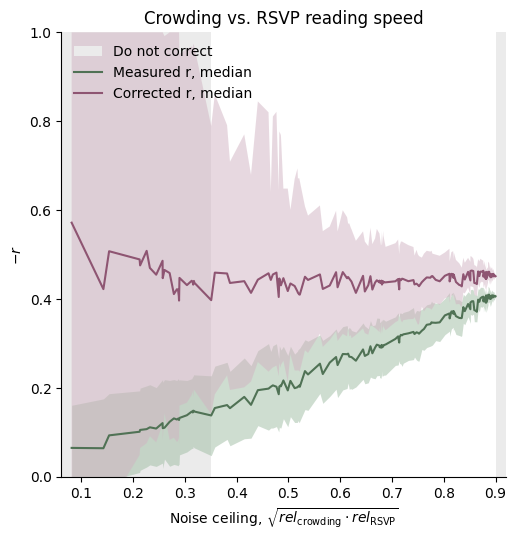

In [24]:
plot_corr_vs_ceiling_median(summarize_draws(results), no_correction=no_correction_ranges.get('all', ()))

## Version 4 with fewer participants
The same analysis with `subset_sizes` (25 and 50) of the 93 participants, chosen at random without replacement.
The trial subsets and QUEST refits are the ones above (a participant's thresholds depend only on their own trials), so only the participants differ. Reliability, noise ceiling and correlations are recomputed from the chosen participants.

Two ways of choosing participants:
- **Redrawn**: a new random set of participants in each draw. The band shows the spread from both trial and participant sampling, like repeating a small study. Because all sets come from the same 93 people, this somewhat understates the spread of truly new samples, especially for 50.
- **Fixed**: one random set of participants, used in every draw. The band shows only the spread from trial sampling, for these people; the median depends on which people were chosen.

Results are saved to `subsample_corr_crowding_rsvp_n<size>_<redrawn or fixed>.csv`.

In [25]:
def subset_thresholds(n, rng, fixed):
    """
    thresholds of n randomly chosen participants (without replacement), for every k and draw.
    fixed=False: a new random set of n participants in each draw. fixed=True: one random set, used in every draw.
    Returns the same form as `thresholds`, with n participants.
    """
    if fixed:
        chosen = np.tile(rng.choice(len(subjects), n, replace=False), (n_draws, 1))
    else:
        chosen = rng.random((n_draws, len(subjects))).argsort(axis=1)[:, :n]
    draws = np.arange(n_draws)[:, None]
    return {task: X[:, draws, chosen, :] for task, X in thresholds.items()}  # (n_k, n_draws, n, n_columns)

In [26]:
rng = np.random.default_rng(seed + 1)  # separate from the trial subsets
results_subset = {}
for n in subset_sizes:
    for fixed in [False, True]:
        choice = 'fixed' if fixed else 'redrawn'
        res, floored, pct = correlation_results(subset_thresholds(n, rng, fixed))
        res['subjects'] = choice
        res.to_csv(f'subsample_corr_crowding_rsvp_n{n}_{choice}.csv', index=False)
        results_subset[(n, choice)] = res
        print(f'{n} participants, {choice}: {len(floored)} (task, k, draw) with a split-half r below {rel_floor}; '
              f'percent of draws capped, largest over (k crowding, k RSVP): {pct.max().max():.1f}')

25 participants, redrawn: 351 (task, k, draw) with a split-half r below 0.01; percent of draws capped, largest over (k crowding, k RSVP): 61.5
25 participants, fixed: 342 (task, k, draw) with a split-half r below 0.01; percent of draws capped, largest over (k crowding, k RSVP): 60.0
50 participants, redrawn: 248 (task, k, draw) with a split-half r below 0.01; percent of draws capped, largest over (k crowding, k RSVP): 53.0
50 participants, fixed: 280 (task, k, draw) with a split-half r below 0.01; percent of draws capped, largest over (k crowding, k RSVP): 46.5


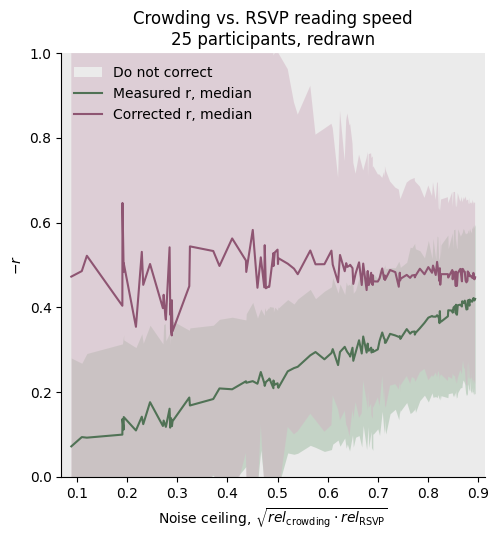

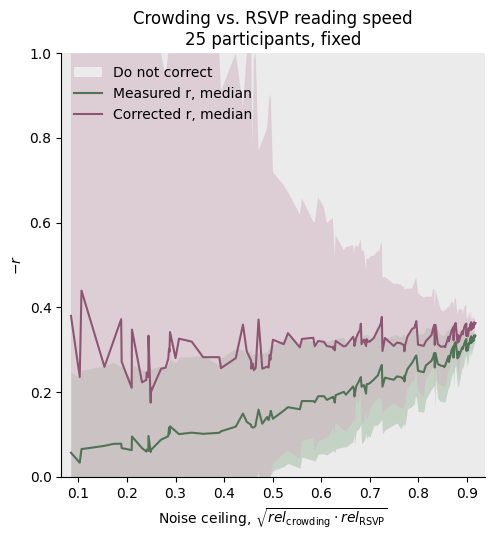

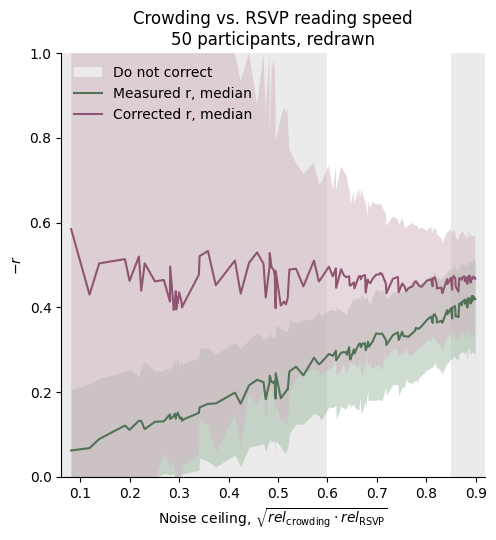

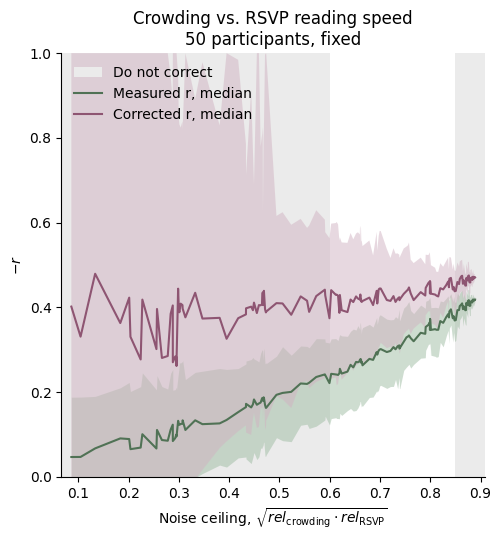

In [27]:
for (n, choice), res in results_subset.items():
    plot_corr_vs_ceiling_median(summarize_draws(res), title=f'Crowding vs. RSVP reading speed\n{n} participants, {choice}',
                                no_correction=no_correction_ranges.get(n, ()))

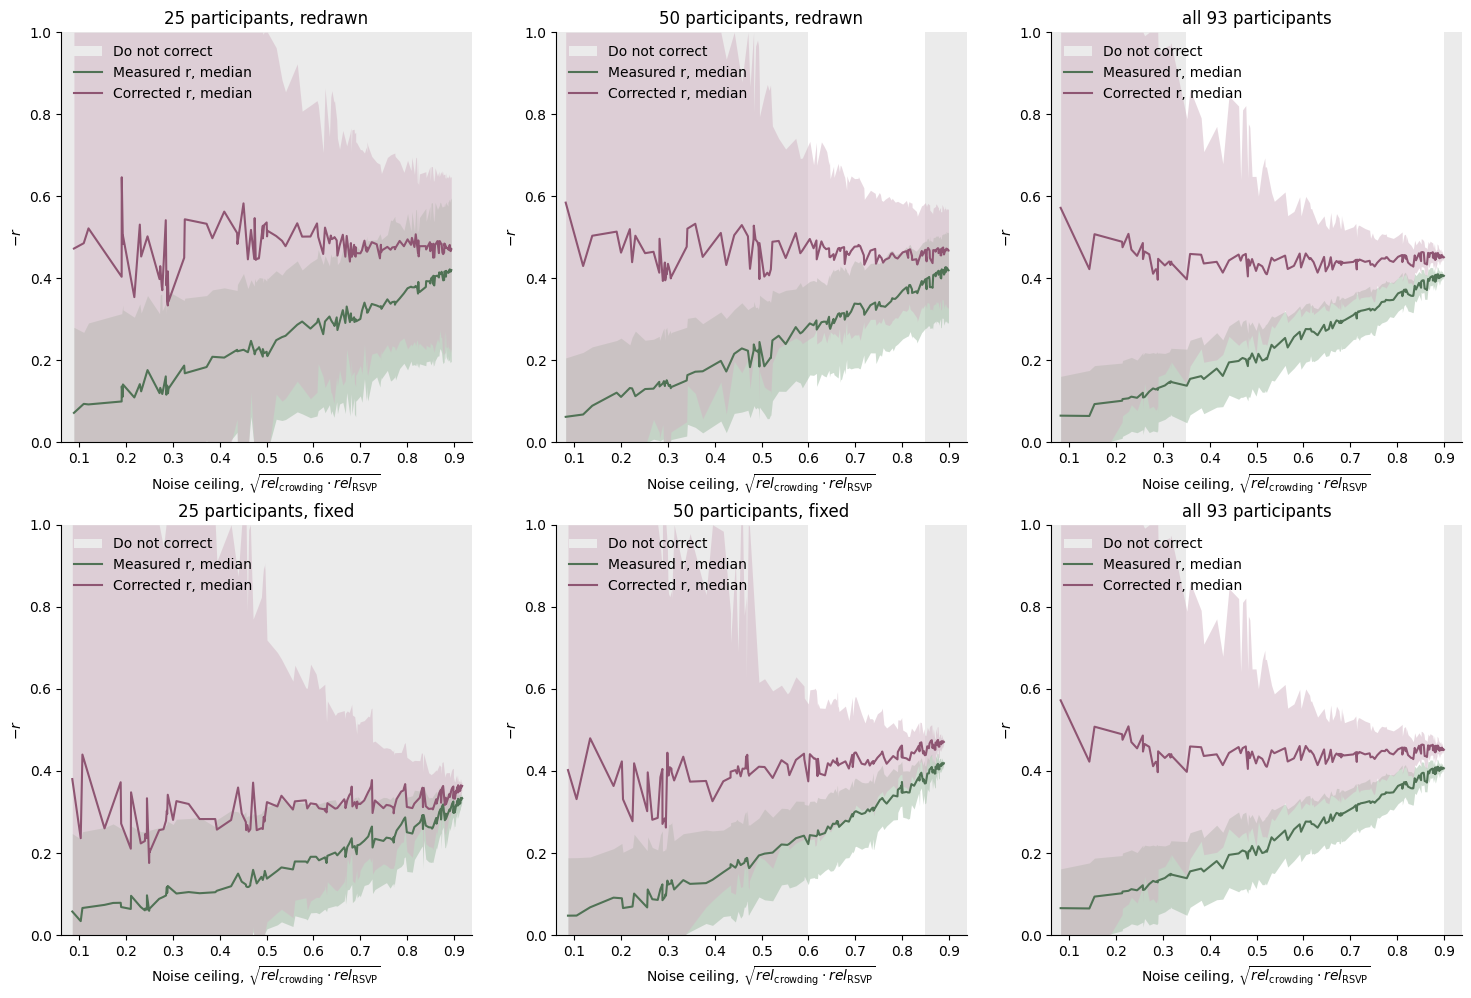

In [28]:
# side by side: rows = how participants were chosen; columns = number of participants (all participants for reference)
choices = ['redrawn', 'fixed']
fig, axes = plt.subplots(len(choices), len(subset_sizes) + 1, figsize=(5 * (len(subset_sizes) + 1), 5 * len(choices)))
for row, choice in enumerate(choices):
    for col, n in enumerate(subset_sizes + [len(subjects)]):
        if n == len(subjects):
            res, label, key = results, f'all {n} participants', 'all'
        else:
            res, label, key = results_subset[(n, choice)], f'{n} participants, {choice}', n
        plot_corr_vs_ceiling_median(summarize_draws(res), title=label, ax=axes[row, col],
                                    no_correction=no_correction_ranges.get(key, ()))

# same x axis in every panel
x_min = min(ax.get_xlim()[0] for ax in axes.flat)
x_max = max(ax.get_xlim()[1] for ax in axes.flat)
for ax in axes.flat:
    ax.set_xlim(x_min, x_max)
plt.tight_layout()
plt.show()

## Version 5: median across draws, smoothed by grouping pairs
Version 4, smoothed. The 100 (k crowding, k RSVP) pairs are sorted by their median noise ceiling across draws, and every `pairs_per_bin` neighboring pairs (default 4) form one bin, giving 25 bins.
In each bin, the dot is the mean of the pairs' median noise ceiling and median -r, and the shaded area spans the mean of their 16th and 84th percentiles of -r (the middle 68%).

In [29]:
def plot_corr_vs_ceiling_median_grouped(summary, pairs_per_bin=4, colors=None, title='Crowding vs. RSVP reading speed'):

    # (label, color of the 68% band, color of the median line)
    series = plot_series(colors)

    # sort pairs by median noise ceiling, then put every pairs_per_bin neighbors in one bin
    summary = summary.sort_values('r_ceiling').reset_index(drop=True)
    pair_bin = summary.index // pairs_per_bin

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r; the 84th percentile of r becomes the lower edge of -r
        strength = summary.assign(y=-summary[col], lo=-summary[f'{col}_q84'], hi=-summary[f'{col}_q16'])
        binned = strength.groupby(pair_bin).agg(x=('r_ceiling', 'mean'), y=('y', 'mean'),
                                                lo=('lo', 'mean'), hi=('hi', 'mean'))
        ax.fill_between(binned['x'], binned['lo'], binned['hi'], color=light_color, alpha=0.5, lw=0, zorder=1)
        ax.plot(binned['x'], binned['y'], color=dark_color, lw=1.5, #marker='o', ms=4,markeredgewidth=0, 
                label=f'{label}, median', zorder=3)

    ax.set_xlim(summary['r_ceiling'].min() - 0.02, summary['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

In [30]:
# plot_corr_vs_ceiling_median_grouped(summarize_draws(results), pairs_per_bin=4)

## Version 6: 68% band across draws, grouped by trial combination, with one example draw
The counterpart of version 1, grouped by (k crowding, k RSVP) combination as in version 4. The shaded area spans each combination's 16th to 84th percentile of -r across draws (the middle 68%), placed at the combination's median noise ceiling and joined in order of it.
The dark line is the example draw (`example_draw`): its -r for each combination, placed at the combination's **median** noise ceiling (not that draw's own estimated ceiling, as in version 1), so the line lines up with the band.

In [31]:
def plot_corr_vs_ceiling_median_band_example(results, example_draw=0, colors=None, title='Crowding vs. RSVP reading speed'):

    # (label, color of the 68% band, color of the example draw)
    series = plot_series(colors)

    # one row per (k crowding, k RSVP) combination, sorted by median noise ceiling across draws
    summary = summarize_draws(results).sort_values('r_ceiling')

    # example draw: its -r per combination, at the combination's median noise ceiling
    example = (results.loc[results['draw'] == example_draw, ['k_crowding', 'k_rsvp', 'r_measured', 'r_corrected']]
               .merge(summary[['k_crowding', 'k_rsvp', 'r_ceiling']], on=['k_crowding', 'k_rsvp'])
               .sort_values('r_ceiling'))

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r; the 84th percentile of r becomes the lower edge of -r
        ax.fill_between(summary['r_ceiling'], -summary[f'{col}_q84'], -summary[f'{col}_q16'],
                        color=light_color, alpha=0.5, lw=0, zorder=1)
        ax.plot(example['r_ceiling'], -example[col], color=dark_color, lw=1.5, label=f'{label}, one draw', zorder=3)

    ax.set_xlim(summary['r_ceiling'].min() - 0.02, summary['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

In [32]:
# plot_corr_vs_ceiling_median_band_example(results, example_draw=example_draw)

# Without nesting (commented out)
This was a one-time check, run with the earlier k grid (k from 6 or 7) and the earlier reliability rule (draws with a negative split-half r left out). It found that nesting does not change the per-(k crowding, k RSVP) summaries.

Same analysis as above (same seed, settings, participants, QUEST refit, reliability, correlation and plots), with one change: the trial subsets are not nested across k.
Above, each draw shuffles a staircase's trials once and keeps the first k for every k, so the trials for a small k are among the trials for every larger k.
Here, each k gets its own random choice of k trials, independent of the trials chosen for the other k in the same draw.
For any single k, both methods choose a random k-trial subset, so the summaries per (k crowding, k RSVP) pair should agree up to random variation.

Results are saved to `subsample_corr_crowding_rsvp_unnested.csv`.

In [33]:
# def subsample_thresholds_unnested(task, rng):
#     """
#     Same as subsample_thresholds, but not nested: for each k, a new random choice of k trials
#     (without replacement) from each staircase, independent of the trials chosen for the other k.
#     """
#     ks = k_grid[task]
#     thresholds = np.full((len(ks), n_draws, len(subjects), len(columns[task])), np.nan)
#     n_short = np.zeros(len(ks), dtype=int)
#
#     for s, prolificID in enumerate(subjects):
#         for c, condition_name in enumerate(columns[task]):
#             t, log_prior, L = quest_tables[(prolificID, condition_name)]
#             n = L.shape[0]
#             for i, k in enumerate(ks):
#                 trial_rank = rng.random((n_draws, n)).argsort(axis=1).argsort(axis=1)  # new random order of trials, per draw and k
#                 chosen = (trial_rank < k).astype(float)
#                 thresholds[i, :, s, c] = quest_mean(t, log_prior + chosen @ L)
#                 n_short[i] += np.isfinite(k) and n < k
#
#     return thresholds, n_short
#
#
# def correlation_results(thresholds):
#     """
#     Same computation as the reliability and correlation cells above.
#     Returns the long-form results (one row per (k crowding, k rsvp, draw)) and the number of
#     (k, draw) with a negative split-half r, per task.
#     """
#     reliability, n_negative = {}, {}
#     for task in ['crowding', 'rsvp']:
#         reliability[task], r_FL, r_OE = split_half_reliability(thresholds[task])
#         n_negative[task] = int(((r_FL < 0) | (r_OE < 0)).sum())
#
#     x = thresholds['crowding'].mean(axis=-1)
#     y = thresholds['rsvp'].mean(axis=-1)
#     zx = (x - x.mean(axis=-1, keepdims=True)) / x.std(axis=-1, keepdims=True)
#     zy = (y - y.mean(axis=-1, keepdims=True)) / y.std(axis=-1, keepdims=True)
#     r_measured = np.einsum('ids,jds->ijd', zx, zy) / len(subjects)
#
#     r_ceiling = np.sqrt(reliability['crowding'][:, None, :] * reliability['rsvp'][None, :, :])
#     r_corrected = r_measured / r_ceiling
#     r_measured = np.where(np.isnan(r_ceiling), np.nan, r_measured)
#
#     i, j, d = np.meshgrid(np.arange(len(k_grid['crowding'])), np.arange(len(k_grid['rsvp'])), np.arange(n_draws), indexing='ij')
#     results = pd.DataFrame({'k_crowding': np.array(k_grid['crowding'])[i.ravel()],
#                             'k_rsvp': np.array(k_grid['rsvp'])[j.ravel()],
#                             'draw': d.ravel(),
#                             'rel_crowding': reliability['crowding'][i.ravel(), d.ravel()],
#                             'rel_rsvp': reliability['rsvp'][j.ravel(), d.ravel()],
#                             'r_ceiling': r_ceiling.ravel(),
#                             'r_measured': r_measured.ravel(),
#                             'r_corrected': r_corrected.ravel()})
#     results['n_subjects'] = len(subjects)
#     return results, n_negative

In [34]:
# output_path_unnested = 'subsample_corr_crowding_rsvp_unnested.csv'
#
# rng = np.random.default_rng(seed)
# thresholds_unnested = {}
# for task in ['crowding', 'rsvp']:
#     thresholds_unnested[task], n_short = subsample_thresholds_unnested(task, rng)
#     print(f'{task}: staircases with fewer than k trials, per k {k_grid[task]}: {n_short.tolist()}')
#
# # RSVP: log10(sec per word) -> log10(words per min), as above
# thresholds_unnested['rsvp'] = np.log10(60) - thresholds_unnested['rsvp']
#
# results_unnested, n_negative = correlation_results(thresholds_unnested)
# print(f'Number of (k, draw) with a negative split-half r: {n_negative}')
# results_unnested.to_csv(output_path_unnested, index=False)

In [35]:
# # compare with the nested results: median across draws per (k crowding, k RSVP) pair, and the difference
# summary_nested = summarize_draws(results).set_index(['k_crowding', 'k_rsvp'])
# summary_unnested = summarize_draws(results_unnested).set_index(['k_crowding', 'k_rsvp'])
# compare_cols = ['r_ceiling', 'r_measured', 'r_corrected', 'r_corrected_q16', 'r_corrected_q84']
# difference = summary_unnested[compare_cols] - summary_nested[compare_cols]
#
# print('Unnested minus nested, across the 100 (k crowding, k RSVP) pairs:')
# display(difference.describe().loc[['mean', 'min', 'max']].round(3))

## Version 3 without nesting
Same as version 3: median and 68% band of -r per group of 800 results, grouped by noise ceiling.

In [36]:
# plot_corr_vs_ceiling_grouped_median(results_unnested, points_per_group=800, title='Crowding vs. RSVP reading speed, not nested')

## Version 4 without nesting
Same as version 4: median and 68% band of -r across draws, per (k crowding, k RSVP) pair, not smoothed.

In [37]:
# plot_corr_vs_ceiling_median(summarize_draws(results_unnested), title='Crowding vs. RSVP reading speed, not nested')